# 분류 기반 이상탐지 — 기계 ID 분류

정상 소리만 사용해 `id_00/02/04/06`을 분류한다.  
테스트 소리가 해당 기계일 확률이 낮을수록 이상으로 판단한다.

- 이상점수: `1 - p(해당 기계)`
- 데이터: MIMII slider -6dB
- 상세 설계: `11_classification_설계.md`


In [2]:
## [0] 준비
# 노트북은 notebooks 폴더에서 실행되므로 프로젝트 루트를 import 경로에 추가한다.
import sys
sys.path.insert(0, '..')

# torch와 다른 라이브러리의 OpenMP 충돌을 막는다.
# 반드시 torch와 matplotlib보다 먼저 설정해야 한다.
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import matplotlib.pyplot as plt
import koreanize_matplotlib
from src import data, train, evaluate
from src.model import IDClassifier

# CUDA가 있으면 GPU로 학습하고, 없으면 CPU를 사용한다.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('학습 장치 :', DEVICE)


학습 장치 : cuda


In [3]:
## [1] 4대 정상 데이터로 기계 ID 분류기 학습
# 각 기계의 정상 데이터를 80:20으로 나누고, 학습 정상 전체 기준으로 정규화한다.
X_trainNP, y_trainNP, tests = data.load_for_classification(seed=42)
print('학습 데이터 shape :', X_trainNP.shape, y_trainNP.shape)

# 모델 초기값과 DataLoader 셔플 순서를 같은 seed로 고정한다.
torch.manual_seed(42)

# 정상 소리의 기계 ID만 정답으로 사용해 4-class 분류기를 학습한다.
model = IDClassifier().to(DEVICE)
model = train.train_classifier(model, X_trainNP, y_trainNP, DEVICE)
print('분류기 학습 완료')


학습 데이터 shape : (2562, 64, 313) (2562,)
분류기 학습 완료


In [4]:
## [2] 기계별 분류 기반 이상탐지 AUC 계산
# 결과를 비교표와 그래프에서 다시 사용하기 위해 딕셔너리에 저장한다.
classification_auc = {}

for machine, test_data in tests.items():
    # test_data에는 기계 index, 테스트 정상, 테스트 이상이 들어 있다.
    machine_idx, test_normalNP, test_abnormalNP = test_data

    # 이상점수 1-p(해당 기계)로 정상과 이상을 얼마나 구분하는지 계산한다.
    auc = evaluate.classifier_auc(
        model, machine_idx, test_normalNP, test_abnormalNP, DEVICE)
    classification_auc[machine] = auc
    print(f'{machine}: 분류 AUC {auc:.4f}')


id_00: 분류 AUC 0.9873
id_02: 분류 AUC 0.9846
id_04: 분류 AUC 0.9473
id_06: 분류 AUC 0.8160


기계 | 복원 AUC | 분류 AUC | 차이
--------------------------------------
id_00 | 0.9400 | 0.9873 | +0.0473
id_02 | 0.7300 | 0.9846 | +0.2546
id_04 | 0.5300 | 0.9473 | +0.4173
id_06 | 0.4800 | 0.8160 | +0.3360


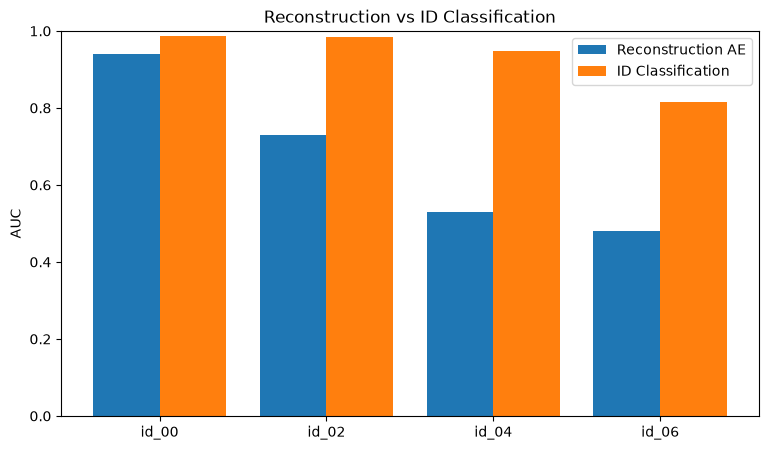

In [5]:
## [3] 복원 AutoEncoder와 분류 방식 결과 비교
# notebook 08에서 확인한 Linear AutoEncoder의 기계별 AUC다.
RECON_AUC = {
    'id_00': 0.94,
    'id_02': 0.73,
    'id_04': 0.53,
    'id_06': 0.48,
}

# 터미널에서도 결과를 확인할 수 있도록 비교표 형태로 출력한다.
print('기계 | 복원 AUC | 분류 AUC | 차이')
print('-' * 38)
for machine in classification_auc:
    recon_auc = RECON_AUC[machine]
    class_auc = classification_auc[machine]
    difference = class_auc - recon_auc
    print(f'{machine} | {recon_auc:.4f} | {class_auc:.4f} | {difference:+.4f}')

# 기초 for문으로 그래프에 사용할 값을 순서대로 만든다.
machines = []
recon_values = []
class_values = []
for machine in classification_auc:
    machines.append(machine)
    recon_values.append(RECON_AUC[machine])
    class_values.append(classification_auc[machine])

# 같은 기계의 복원 방식과 분류 방식을 나란히 표시한다.
xpos = np.arange(len(machines))
plt.figure(figsize=(9, 5))
plt.bar(xpos - 0.2, recon_values, width=0.4, label='복원 AutoEncoder')
plt.bar(xpos + 0.2, class_values, width=0.4, label='기계 ID 분류')
plt.xticks(xpos, machines)
plt.ylim(0.0, 1.0)
plt.ylabel('AUC')
plt.title('복원 방식과 기계 ID 분류 방식 비교')
plt.legend()
plt.show()


## 다중 seed 강건성 검증

단일 seed에서 확인한 분류 성능이 데이터 분할과 모델 초기값이 바뀌어도 유지되는지 검증한다.  
notebook 07·10과 동일하게 seed 0~4를 사용하고, 기계별 AUC 평균과 표준편차를 계산한다.


In [6]:
## [4] 분류 모델을 5개 seed로 반복 학습하고 기계별 AUC 수집
# 기존 강건성 실험과 같은 seed를 사용한다.
SEEDS = [0, 1, 2, 3, 4]
MACHINES = ['id_00', 'id_02', 'id_04', 'id_06']

# 각 기계의 seed별 AUC를 따로 모으기 위한 딕셔너리다.
auc_by_machine = {}
for machine in MACHINES:
    auc_by_machine[machine] = []

for seed in SEEDS:
    # 모델 초기값과 DataLoader 셔플 순서를 현재 seed로 고정한다.
    torch.manual_seed(seed)

    # 같은 seed로 기계별 정상 데이터를 80:20 분할하고 전역 정규화한다.
    X_trainNP, y_trainNP, seed_tests = data.load_for_classification(seed=seed)

    # seed마다 새로운 ID 분류기를 만들고 정상 소리만 학습한다.
    seed_model = IDClassifier().to(DEVICE)
    seed_model = train.train_classifier(
        seed_model, X_trainNP, y_trainNP, DEVICE)

    # 같은 모델로 네 기계의 정상/이상 분리 AUC를 각각 계산한다.
    for machine, test_data in seed_tests.items():
        machine_idx, test_normalNP, test_abnormalNP = test_data
        auc = evaluate.classifier_auc(
            seed_model, machine_idx, test_normalNP, test_abnormalNP, DEVICE)
        auc_by_machine[machine].append(auc)
        print(f'seed {seed} / {machine}: AUC {auc:.4f}')


seed 0 / id_00: AUC 0.9815
seed 0 / id_02: AUC 0.8950
seed 0 / id_04: AUC 0.9845
seed 0 / id_06: AUC 0.8526
seed 1 / id_00: AUC 0.9881
seed 1 / id_02: AUC 0.9681
seed 1 / id_04: AUC 0.9714
seed 1 / id_06: AUC 0.6649
seed 2 / id_00: AUC 0.9929
seed 2 / id_02: AUC 0.9311
seed 2 / id_04: AUC 0.9719
seed 2 / id_06: AUC 0.7344
seed 3 / id_00: AUC 0.9923
seed 3 / id_02: AUC 0.8997
seed 3 / id_04: AUC 0.9982
seed 3 / id_06: AUC 0.7499
seed 4 / id_00: AUC 0.8982
seed 4 / id_02: AUC 0.8571
seed 4 / id_04: AUC 0.9848
seed 4 / id_06: AUC 0.8141


In [7]:
## [5] 기계별 AUC 평균 ± 표준편차와 단일 seed 결과 비교
# 지시 #4에서 얻은 seed 42 단일 실행 결과다.
SINGLE_SEED_AUC = {
    'id_00': 0.9850,
    'id_02': 0.9846,
    'id_04': 0.9573,
    'id_06': 0.7601,
}

# 기계별 5개 AUC를 ndarray로 바꾸고 평균과 모집단 표준편차를 계산한다.
multi_seed_summary = {}
print('기계 | 단일 seed | 다중 seed 평균 ± 표준편차')
print('-' * 58)
for machine in MACHINES:
    aucsNP = np.array(auc_by_machine[machine])
    AUC_MEAN = aucsNP.mean()
    AUC_STD = aucsNP.std()
    multi_seed_summary[machine] = (AUC_MEAN, AUC_STD)
    print(
        f'{machine} | {SINGLE_SEED_AUC[machine]:.4f} | '
        f'{AUC_MEAN:.4f} ± {AUC_STD:.4f}')


기계 | 단일 seed | 다중 seed 평균 ± 표준편차
----------------------------------------------------------
id_00 | 0.9850 | 0.9706 ± 0.0364
id_02 | 0.9846 | 0.9102 ± 0.0373
id_04 | 0.9573 | 0.9822 ± 0.0099
id_06 | 0.7601 | 0.7632 ± 0.0652


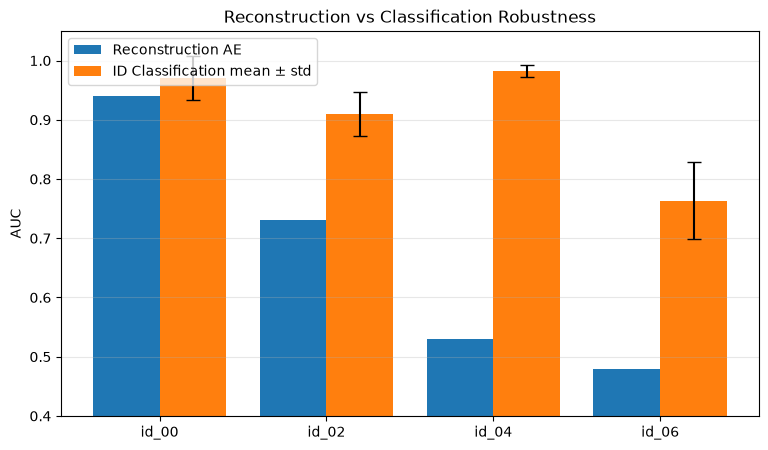

In [8]:
## [6] 기계별 복원 기준과 분류 다중 seed 성능 시각화
# 평균 막대와 표준편차 error bar를 함께 표시해 성능과 안정성을 동시에 비교한다.
machines = []
recon_values = []
classification_means = []
classification_stds = []

for machine in MACHINES:
    AUC_MEAN, AUC_STD = multi_seed_summary[machine]
    machines.append(machine)
    recon_values.append(RECON_AUC[machine])
    classification_means.append(AUC_MEAN)
    classification_stds.append(AUC_STD)

xpos = np.arange(len(machines))
plt.figure(figsize=(9, 5))
plt.bar(xpos-0.2, recon_values, width=0.4, label='복원 AutoEncoder')
plt.bar(
    xpos+0.2, classification_means, width=0.4,
    yerr=classification_stds, capsize=5, label='기계 ID 분류 평균 ± 표준편차')
plt.xticks(xpos, machines)
plt.ylim(0.4, 1.05)
plt.ylabel('AUC')
plt.title('복원 기준과 분류 다중 시드 성능 비교')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()


In [ ]:
## [7] README용 복원 vs 분류 대표 그래프 저장
# CUDA 재실행 오차로 README 수치가 바뀌지 않도록 #5에서 승인된 결과를 사용한다.
README_MACHINES = ['id_00', 'id_02', 'id_04', 'id_06']
README_RECON_AUC = [0.9400, 0.7300, 0.5300, 0.4800]
README_CLASS_MEAN = [0.9472, 0.8905, 0.9863, 0.7617]
README_CLASS_STD = [0.0776, 0.0946, 0.0100, 0.0671]

xpos = np.arange(len(README_MACHINES))
plt.figure(figsize=(9, 5))
plt.bar(xpos-0.2, README_RECON_AUC, width=0.4, label='복원 AutoEncoder')
plt.bar(
    xpos+0.2, README_CLASS_MEAN, width=0.4, yerr=README_CLASS_STD,
    capsize=5, label='기계 ID 분류 평균 ± 표준편차')
plt.xticks(xpos, README_MACHINES)
plt.ylim(0.4, 1.05)
plt.ylabel('AUC')
plt.title('복원 기준과 분류 다중 시드 성능 비교')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.savefig('../assets/recon_vs_classification.png', dpi=120, bbox_inches='tight')
plt.show()


## 결과 해석

| 기계 | 복원 AUC | 분류 단일 seed | 분류 다중 seed |
|:----:|:--------:|:--------------:|:---------------:|
| id_00 | 0.9400 | 0.9850 | **0.9472 ± 0.0776** |
| id_02 | 0.7300 | 0.9846 | **0.8905 ± 0.0946** |
| id_04 | 0.5300 | 0.9573 | **0.9863 ± 0.0100** |
| id_06 | 0.4800 | 0.7601 | **0.7617 ± 0.0671** |

- 다중 seed 평균에서도 네 기계 모두 복원 AutoEncoder보다 높은 AUC를 보였다.
- 핵심 난제였던 id_04는 `0.9863 ± 0.0100`으로 매우 높고 안정적이다.
- id_06도 평균 0.7617로 복원 0.48보다 크게 개선됐지만 표준편차 0.0671로 변동이 있다.
- id_00/02는 seed 4에서 성능이 크게 낮아져 표준편차가 각각 0.0776/0.0946이다. 따라서 모든 기계에서 안정적이라고 단정할 수 없다.
- 결론적으로 분류 방식의 평균 우위는 유지되지만, id_00/02의 학습 안정성 원인은 추가 진단이 필요하다.
